In [1]:
# Autoreload custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os

import pandas as pd
import json

import numpy as np
import jax
import jax.numpy as jnp
import optax

import time
import importlib
import matplotlib.pyplot as plt

In [ ]:
# import custom modules
sys.path.append('..')

from models.models import DecoderOnlyTransformer
from util.data_loader import load_data, encode, decode, get_batch
from util.optimization import train_step, loss_and_metrics, create_train_state

In [ ]:
# initialize jax random key
master_key = jax.random.PRNGKey(0)

In [ ]:
# load dataset
train_data, test_data, ctoi, itoc, vocab_size = load_data(encoded_path='../data/encoded.pkl')

#### Parameters

In [ ]:
# Model parameters
d_model = 256
n_heads = 4
n_layers = 4 # Based on model_arch experiment

# Training parameters
learning_rate = 5e-4
niter = 5000

In [ ]:
# Create multiple batch size and seq len config for experiments
batch_sizes = [64, 128, 256]
seq_lens = [32, 64, 128]
configs = [(B, T) for B in batch_sizes for T in seq_lens]

#### Training loop

In [ ]:
results_summary = []

In [ ]:
# Train loop

for B, T in configs:
    start_time = time.time() # Should have put this in the for loop
    print(f"Training model with batch_size={B}, seq_len={T}")

    cur_iter = 0
    while True:
        if cur_iter == 0:
            # initialize model for current architecture
            master_key, init_key = jax.random.split(master_key)
            model, params = create_train_state(init_key, vocab_size=vocab_size, d_model=d_model, n_layers=n_layers, n_heads=n_heads, max_len=T) # No dropout for now

            # Create Adam optimizer
            tx = optax.adam(learning_rate)
            # initialize training state
            opt_state = tx.init(params)
            print(f'Initialized Optimizer: Adam with learning rate {learning_rate}')

            # Create empty lists for storing metrics
            loss_history = []
            time_history = []
            test_loss_history = []
            test_time_history = []

        input, target = get_batch(train_data, B, T)
        # perform a training step
        params_new, opt_state_new, metrics = train_step(model, params, opt_state, input, target, tx)

        # uodate params and opt_state
        params = params_new
        opt_state = opt_state_new
        # get metrics
        acc = metrics['acc']
        acc_last = metrics['acc_last']
        loss = metrics['loss']

        # append to history
        loss_history.append(loss)
        time_history.append(time.time() - start_time)

        # Evaluate on test set regularly
        if cur_iter % (niter // 50) == 0 or cur_iter == niter - 1:
            time_since_start = time.time() - start_time
            B_test, T_test = 1024, T # larger batch size for evaluation
            test_input, test_target = get_batch(test_data, B_test, T_test)
            test_logits = model.apply({'params': params}, test_input)
            test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
            test_acc = test_metrics['acc']
            test_acc_last = test_metrics['acc_last']
            test_loss_history.append(test_loss)
            test_time_history.append(time_since_start)
            print(f"iteration {cur_iter:_}  time: {time_since_start:.1f} seconds")
            print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
            print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
            print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
            print()

        cur_iter += 1
        if cur_iter >= niter:
            # store history for this config
            results_summary.append({
                '(Batch_size, seq_len)': (B, T),
                'train_loss_history': loss_history,
                'train_time_history': time_history,
                'test_loss_history': test_loss_history,
                'test_time_history': test_time_history,
            })
            break


Training model with batch_size=64, seq_len=32
Initialized Optimizer: Adam with learning rate 0.0005
iteration 0  time: 10.7 seconds
	 	 loss(train :: test): 3.6975 :: 4.4398
	 	 accuracy (train :: test): 3.3% :: 17.5%
	 	 accuracy (last character) (train :: test): 3.1% :: 17.3%

iteration 100  time: 15.9 seconds
	 	 loss(train :: test): 2.3234 :: 2.3530
	 	 accuracy (train :: test): 28.9% :: 29.2%
	 	 accuracy (last character) (train :: test): 21.9% :: 26.9%

iteration 200  time: 17.4 seconds
	 	 loss(train :: test): 2.1405 :: 2.1830
	 	 accuracy (train :: test): 34.3% :: 33.5%
	 	 accuracy (last character) (train :: test): 32.8% :: 33.9%

iteration 300  time: 19.0 seconds
	 	 loss(train :: test): 1.9852 :: 1.9787
	 	 accuracy (train :: test): 39.4% :: 39.6%
	 	 accuracy (last character) (train :: test): 43.8% :: 38.1%

iteration 400  time: 20.6 seconds
	 	 loss(train :: test): 1.9502 :: 1.8921
	 	 accuracy (train :: test): 41.0% :: 42.1%
	 	 accuracy (last character) (train :: test): 

save results

In [ ]:
# Convert JAX arrays to lists
def convert_to_list(obj):
    if isinstance(obj, dict):
        return {k: convert_to_list(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_list(item) for item in obj]
    elif isinstance(obj, jax.numpy.ndarray):
        return obj.tolist() # Convert JAX array to Python list
    else:
        return obj

In [ ]:
if len(results_summary) == 9:
    results_serializable = convert_to_list(results_summary)

    with open("../results/batch_config_training_results.json", "w") as f:
      json.dump(results_serializable, f)

Analyse results

In [3]:
with open("../results/batch_config_training_results.json", "r") as f:
      results_summary = json.load(f)

In [4]:
def build_results_table(results_summary):
    rows = []

    for item in results_summary:
        (B, T) = item['(Batch_size, seq_len)']

        train_loss = item['train_loss_history']
        test_loss  = item['test_loss_history']
        train_time = item['train_time_history']

        final_train_loss = train_loss[-1]
        final_test_loss  = test_loss[-1]
        min_test_loss    = np.min(test_loss)
        gap = final_test_loss - final_train_loss

        # steps to reach 5% above min test loss
        target = min_test_loss * 1.05
        steps_to_5 = next((i for i, l in enumerate(test_loss) if l <= target), len(test_loss))

        rows.append({
            "Batch": B,
            "Seq Len": T,
            "Final Train Loss": final_train_loss,
            "Final Test Loss": final_test_loss,
            "Min Test Loss": min_test_loss,
            "Generalization Gap": gap,
            "Steps to 5%": steps_to_5,
        })

    return pd.DataFrame(rows)

df = build_results_table(results_summary)
df

,Batch,Seq Len,Final Train Loss,Final Test Loss,Min Test Loss,Generalization Gap,Steps to 5%
0,64,32,1.535346,1.440242,1.437507,-0.095104,23
1,64,64,1.301715,1.369547,1.353496,0.067831,27
2,64,128,1.283284,1.318451,1.307660,0.035168,27
3,128,32,1.406946,1.391399,1.391399,-0.015547,26
4,128,64,1.294744,1.338514,1.319330,0.043770,27
5,128,128,1.320984,1.299517,1.298535,-0.021467,27
6,256,32,1.385998,1.380419,1.357518,-0.005579,21
7,256,64,1.263573,1.295598,1.294736,0.032025,23
8,256,128,1.209083,1.233562,1.233562,0.024479,28


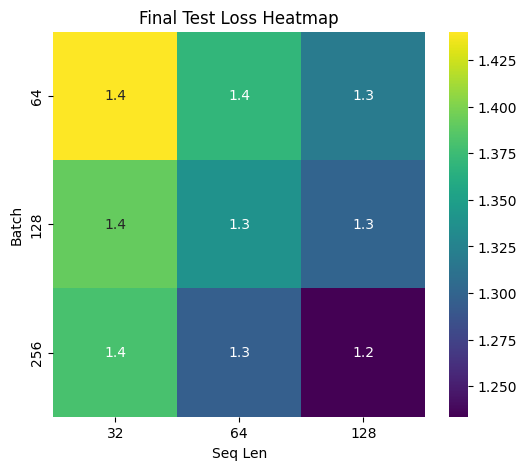

In [5]:
import seaborn as sns

pivot = df.pivot(index="Batch", columns="Seq Len", values="Final Test Loss")

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap="viridis")
plt.title("Final Test Loss Heatmap")
plt.show()
